# End-to-End Machine Learning Project

The main steps you will go through in this course and your projects are: 

1. ~~Look at the big picture.~~
2. ~~Get the data.~~
3. ~~Discover and visualize the data to gain insights.~~
4. ~~Prepare the data for Machine Learning algorithms.~~
5. ~~Select a model and train it.~~
6. Fine-tune your model. 
7. Present your solution. 
8. Launch, monitor, and maintain your system.

---

# Ways to Avoid Overfitting

1. Add more data! - when possible

2. Occam's Razor - select a model with lower complexity

3. Cross-validation - use the training data to fine-tune hyperparameter of the mapper function

4. Regularization - constrains/regularizes the coefficients of the model

## Cross-Validation

The goal of **cross-validation**, or CV, is to test the model's ability to predict new data that was not used in estimating the model, in order to flag problems like overfitting or selection bias and to give an insight on how the model will generalize to an independent dataset (i.e., an unknown dataset).

Cross-validation allows us to determine the values for the hyperparameter that provide the most **generalization**. Cross-validation mitigates the occurrence of **overfitting**, but it does not eliminate it entirely.

Let's consider the **MSE** as our performance measure. There are different strategies for implementing cross-validation:

1. **k-fold cross-validation**. Training set is partitioned into $k$ folds.
2. **Leave-One-Out cross-validation**. Extreme case, where only one sample is left for validation.
3. **Stratified cross-validation**. Data is partition such that each class prior probability is preserved.
4. **$k\times 2$ cross-validation**. Training data is partitioned into 2 sets of equal size $k$ times.

### K-Fold Cross-Validation

The technique of k-fold cross-validation, illustrated below for the case of $k=4$, involves taking the available data and partitioning it into $k$ groups (in the simplest case these are of equal size). Then $k-1$ of the groups are used to train a set of models that are then evaluated on the remaining group. This procedure is then repeated for all $k$ possible choices for the held-out group, indicated in the picture below by the red blocks, and the performance scores from the runs are then averaged.

$K$ is typically 10 or 30. As $K$ increases, the percentage of training instances increases and we get more robust estimators, but the validation set becomes smaller. Furthermore, there is the cost of training the classiﬁer $K$ times, which increases as $K$ is increased. As $N$ increases, $K$ can be smaller; if $N$ is small, $K$ should be large to allow large enough training sets.

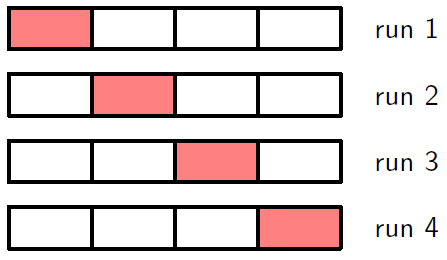

In [1]:
from IPython.display import Image
Image('figures\\Kfold CV.png',width=400)

The following code randomly splits the training set into 10 distinct subsets called **folds**, then it trains and evaluates the model 10 times, picking a different fold for evaluation every time and training on the other 9 folds. 

The result is an array containing the 10 evaluation scores:

In [30]:
from sklearn.model_selection import cross_val_score 
from sklearn.model_selection import KFold

cross_val_score?

In [31]:
scores = cross_val_score(model2,
                        X_train,
                        t_train,
                        scoring='neg_mean_squared_error',
                        cv=KFold(10, random_state=0, shuffle=True))

# cross_val_score it searches for the value that MAXIMIZES the scoring function.

Find more ```scoring``` metrics in the ```scikit-learn``` API [model evaluation](https://scikit-learn.org/stable/modules/model_evaluation.html).

In [32]:
scores

array([-5.31852770e+09, -5.37294764e+09, -4.42376185e+09, -5.06109587e+09,
       -4.63305216e+09, -4.84380227e+09, -4.73242181e+09, -5.04242304e+09,
       -5.32490911e+09, -4.77784899e+09])

In [33]:
rmse_scores = np.sqrt(-scores)

rmse_scores

array([72928.23665837, 73300.39321071, 66511.36633875, 71141.37941942,
       68066.52746781, 69597.43002044, 68792.59997931, 71010.02072952,
       72971.97482709, 69121.98630209])

```Scikit-Learn```'s cross-validation features expect a utility function (greater is better) rather than a cost function (lower is better), so the scoring function is actually the opposite of the MSE (i.e., a negative value), which is why the preceding code computes ```-scores``` before calculating the square root. 

Let's look at the results:

In [34]:
def display_scores(scores):
    print('Scores:', scores)
    print('Mean:', scores.mean())
    print('Standard deviation:', scores.std())
    
display_scores(rmse_scores)

Scores: [72928.23665837 73300.39321071 66511.36633875 71141.37941942
 68066.52746781 69597.43002044 68792.59997931 71010.02072952
 72971.97482709 69121.98630209]
Mean: 70344.1914953506
Standard deviation: 2184.8953510696556


Let's compute the same scores for the Linear Regression model just to be sure:

In [35]:
lin_reg_scores = cross_val_score(model, # now it uses the linear regression model
                        X_train,
                        t_train,
                        scoring='neg_mean_squared_error',
                        cv=KFold(10, random_state=0, shuffle=True))

# cross_val_score it searches for the value that MAXIMIZES the scoring function.

display_scores(np.sqrt(-lin_reg_scores))

Scores: [69224.31849412 69113.59743973 68092.37193773 66189.10546646
 66609.47956814 64797.7709124  72462.4660725  68294.11170892
 72604.90116056 66613.08557631]
Mean: 68400.12083368798
Standard deviation: 2444.228497244148


Let's try one last model now: the ```RandomForestRegressor```. (We will study this model in detail later on in the course.)

Random Forests work by training many Decision Trees on random subsets of the features, then averaging out their predictions. Building a model on top of many other models is called **Ensemble Learning**, and it is often a great way to push ML algorithms even further.

In [36]:
from sklearn.ensemble import RandomForestRegressor

# Model 3: define pipeline
model3 = Pipeline([('preprocess', preprocessing),
                  ('random_forest', RandomForestRegressor())])

# Train model
model3.fit(X_train, t_train)

# Make model predictions
y_train = model3.predict(X_train)
y_test = model3.predict(X_test)

In [37]:
# Evaluate performance on validation folds
forest_scores = cross_val_score(model3,
                                X_train, 
                                t_train, 
                                scoring='neg_mean_squared_error', 
                                cv=KFold(10, random_state=0, shuffle=True)) 

forest_rmse_scores = np.sqrt(-forest_scores)

display_scores(forest_rmse_scores)

Scores: [54584.06381568 50738.32858607 49660.43793738 48337.15711451
 47584.94350955 48441.38246718 50739.17215463 50997.33094534
 51954.53673234 48904.11070376]
Mean: 50194.14639664356
Standard deviation: 1971.95864389299


Much better!

But, the score on the training set is still much lower than on the validation sets, meaning that the model is **still overfitting the training set**. 

Possible solutions for overfitting are to simplify the model, constrain it (i.e., regularize it), or get a lot more training data. Before you dive much deeper into Random Forests, however, you should try out many other models from various categories of Machine Learning algorithms (e.g., several Support Vector Machines with different kernels, and possibly a neural network), without spending too much time tweaking the hyperparameters. The goal is to shortlist a few (two to five) promising models.

## Regularization

---

In [28]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, KFold
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, MinMaxScaler, StandardScaler
import matplotlib.pyplot as plt
%matplotlib inline
plt.style.use('bmh')

In [2]:
def NoisySinusoidalData(N, a, b, sigma):
    '''Generates N data points in the range [a,b) sampled from a sin(2*pi*x) 
    with additive zero-mean Gaussian random noise with standard deviation sigma'''
    
    # N input samples, evenly spaced numbers between [a,b) incrementing by 1/N
    x = np.linspace(a,b,N)
    
    # draw N sampled from a univariate Gaussian distribution with mean 0, sigma standard deviation and N data points
    noise = np.random.normal(0,sigma,N)
    
    # desired values, noisy sinusoidal
    t = np.sin(2*np.pi*x) + noise
    
    return x.reshape(-1,1), t

In [3]:
# Generate input samples and desired values
N_train = 50 # number of data samples for training
N_test = 20 # number of data samples for test

a, b = [0,1] # data samples interval

sigma_train = 0.3 # standard deviation of the zero-mean Gaussian noise -- training data
sigma_test = 0.4 # standard deviation of the zero-mean Gaussian noise -- test data

x_train, t_train = NoisySinusoidalData(N_train, a, b, sigma_train) # Training Data - Noisy sinusoidal
x_true, t_true = NoisySinusoidalData(N_train, a, b, 0) # True Sinusoidal - in practice, we don't have the true function
x_test, t_test = NoisySinusoidalData(N_test, a, b, sigma_test) # Test Data - Noisy sinusoidal

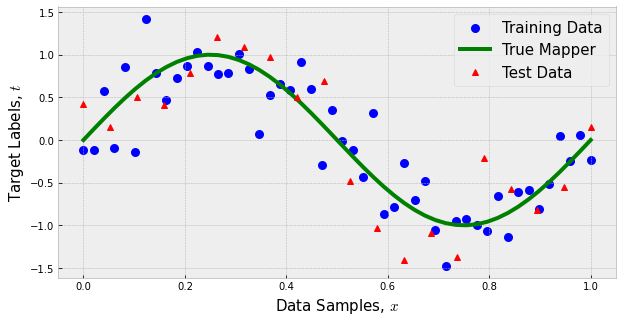

In [6]:
plt.figure(figsize=(10,5))
plt.scatter(x_train, t_train, c='b', linewidths=3, label = 'Training Data')
plt.plot(x_true, t_true, 'g', linewidth=4, label = 'True Mapper')
plt.plot(x_test, t_test, 'r^', label = 'Test Data')
plt.legend(fontsize=15)
plt.xlabel('Data Samples, $x$',size=15)
plt.ylabel('Target Labels, $t$',size=15);

The input data in this problem is a single input. We can construct new attributes from this single input. Namely, we will be constructing **polynomial basis functions**.

Let $\{(x_i,t_i)\}_{i=1}^N$ be a set of training data samples, where each sample $x_i$ and target $t_i$ are continuous-valued, i.e. $x_i, t_i \in\mathbb{R}$.

1. **Feature Space:** we can create a *deterministic* set of features with, for example, a polynomial basis function:

\begin{align*}
\phi: \mathbb{R} &\longrightarrow \mathbb{R}^{M+1}\\
x &\longmapsto \begin{bmatrix}\phi_0(x) & \phi_1(x) & \phi_2(x) & \dots &\phi_M(x) \end{bmatrix}^T\\
x &\longmapsto \begin{bmatrix}x^0 &x^1&x^2&\dots&x^M\end{bmatrix}^T
\end{align*}

That is, for every ample $x_i$ in training, we map to the polynomial basis feature space: $\phi(x_i) = \left[1, x_i, x_i^2, \dots, x_i^M\right]^T, \forall i$.

Let $\mathbf{x}$ be the vector containing all training samples, i.e. $\mathbf{x}=\begin{bmatrix}x_1 & x_2 &  x_2 & \dots & x_N\end{bmatrix}^T$. We can build a **feature matrix** (or **data matrix**) of size $N\times (M+1)$ that contains this polynomial feature representation:

\begin{align*}
\mathbf{X} = \begin{bmatrix}\phi_0(\mathbf{x}) & \phi_1(\mathbf{x}) & \phi_2(\mathbf{x}) & \dots & \phi_M(\mathbf{x})\end{bmatrix} = \begin{bmatrix} \phi(x_1)^T \\ \phi(x_2)^T \\ \vdots \\ \phi(x_N)^T \end{bmatrix} = \begin{bmatrix}1 & x_{1} & x_{1}^{2} & \cdots & x_{1}^M\\
1 & x_{2} & x_{2}^{2} & \cdots & x_{2}^M\\
\vdots & \vdots & \vdots & \ddots & \vdots\\
1 & x_{N} & x_{N}^{2} & \cdots & x_{N}^M
\end{bmatrix}
\end{align*}

Alternatively, we can make use of ```scikit-learn``` functions:

In [8]:
from sklearn.preprocessing import PolynomialFeatures

# PolynomialFeatures?

In [9]:
M = 3 # model order

pol_feat = PolynomialFeatures(degree=M)

#feature matrix
train_set = pol_feat.fit_transform(x_train)

train_set.shape

(50, 4)

In [10]:
# Visualize it as a pandas dataframe (This step is NOT REQUIRED)

data = pd.DataFrame(train_set,
             columns=['x^'+str(i) for i in range(M+1)])

data.head()

,x^0,x^1,x^2,x^3
0,1.0,0.000000,0.000000,0.000000
1,1.0,0.020408,0.000416,0.000008
2,1.0,0.040816,0.001666,0.000068
3,1.0,0.061224,0.003748,0.000229
4,1.0,0.081633,0.006664,0.000544


Now, let's fit a linear regression model, which is just a linear combination of these polynomial features:

2. **Mapper**: a linear combination of features weighted by a set of parameters $\mathbf{w}=\left[w_0, w_1, w_2,\dots, w_M\right]^T$, taking the form

$$y = f(\phi(x),\mathbf{w}) = \sum_{j=0}^{M} w_j\phi_j(x)$$

or, in matrix form,

$$y = f(\phi(x),\mathbf{w}) = \mathbf{X}\mathbf{w}$$

3. **Objective Function**: function that assesses the *quality* of the output of the model, for example, an error-based function such as L2-norm of the error or the mean-squared error (MSE) function:

$$J(\mathbf{w}) = \frac{1}{2} \sum_{n=1}^N \left(t_n - f(\phi(x_n),\mathbf{w})\right)^2 = \frac{1}{2}\left\Vert \mathbf{t} - \mathbf{X}\mathbf{w} \right\Vert^2_2$$

4. **Learning Algorithm**: an algorithm that solves or searches for the *optimal* values of the parameters $\mathbf{w}$ that optimize the objective function. It solves the following optimization problem:

$$\arg_{\mathbf{w}}\min J(\mathbf{w})$$

Because the selected model is linear on the parameters and our objective function is convex, we can solve for a solution analytical without having to resort to search algorithms such as the gradient descent.

Since this is a linear model on the parameters $\mathbf{w}$, and the objective function is a *convex* objective function, we can compute the solution analytically. It looks like: 

\begin{align*}
\mathbf{w} = \left(\mathbf{X}^T\mathbf{X}\right)^{-1}\mathbf{X}^T\mathbf{t}
\end{align*}

In [11]:
lin_reg = LinearRegression()

In [12]:
lin_reg.fit(train_set, t_train)

LinearRegression()

In [13]:
lin_reg.intercept_

#w0

-0.23272598369961855

In [14]:
lin_reg.coef_

#[w1,w2,...,wM]

array([  0.        ,  11.23515065, -32.14141784,  21.27276162])

In [15]:
lin_reg.coef_[1:]

array([ 11.23515065, -32.14141784,  21.27276162])

In [16]:
# Concatenate bias and coefficients in the same parameter vector

w = np.hstack((lin_reg.intercept_, lin_reg.coef_[1:])).reshape(-1,1) # casts it as a column vector

w, w.shape

(array([[ -0.23272598],
        [ 11.23515065],
        [-32.14141784],
        [ 21.27276162]]),
 (4, 1))

In [17]:
# using the equation above

w = np.linalg.inv(train_set.T@train_set)@train_set.T@t_train
w

array([ -0.23272598,  11.23515065, -32.14141784,  21.27276162])

Now that we have trained the parameters, we can use it to make predictions in both training and test sets.

In [18]:
## Use the mapper function to make predictions "manually"

train_set@w

array([-0.23272598, -0.01664306,  0.1737514 ,  0.33954228,  0.48181449,
        0.6016529 ,  0.70014243,  0.77836795,  0.83741436,  0.87836656,
        0.90230943,  0.91032787,  0.90350678,  0.88293104,  0.84968555,
        0.80485521,  0.74952489,  0.68477951,  0.61170395,  0.5313831 ,
        0.44490185,  0.35334511,  0.25779776,  0.15934469,  0.05907081,
       -0.04193901, -0.14259986, -0.24182686, -0.3385351 , -0.4316397 ,
       -0.52005577, -0.6026984 , -0.67848272, -0.74632382, -0.80513681,
       -0.8538368 , -0.8913389 , -0.91655821, -0.92840984, -0.9258089 ,
       -0.90767049, -0.87290973, -0.82044171, -0.74918155, -0.65804435,
       -0.54594522, -0.41179927, -0.25452161, -0.07302733,  0.13376845])

Equivalently, we can call the ```transform``` method to compute the model predictions:

In [19]:
y_train = lin_reg.predict(train_set)

y_train

array([-0.23272598, -0.01664306,  0.1737514 ,  0.33954228,  0.48181449,
        0.6016529 ,  0.70014243,  0.77836795,  0.83741436,  0.87836656,
        0.90230943,  0.91032787,  0.90350678,  0.88293104,  0.84968555,
        0.80485521,  0.74952489,  0.68477951,  0.61170395,  0.5313831 ,
        0.44490185,  0.35334511,  0.25779776,  0.15934469,  0.05907081,
       -0.04193901, -0.14259986, -0.24182686, -0.3385351 , -0.4316397 ,
       -0.52005577, -0.6026984 , -0.67848272, -0.74632382, -0.80513681,
       -0.8538368 , -0.8913389 , -0.91655821, -0.92840984, -0.9258089 ,
       -0.90767049, -0.87290973, -0.82044171, -0.74918155, -0.65804435,
       -0.54594522, -0.41179927, -0.25452161, -0.07302733,  0.13376845])

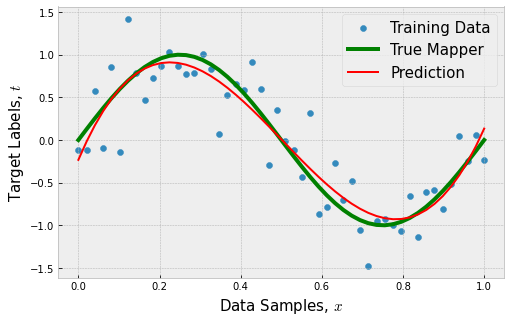

In [20]:
plt.figure(figsize=(8,5))
plt.scatter(x_train, t_train, label='Training Data')
plt.plot(x_true, t_true, 'g', linewidth=4, label = 'True Mapper')
plt.plot(x_train, y_train, c='r', label='Prediction')
plt.legend(fontsize=15)
plt.xlabel('Data Samples, $x$',size=15)
plt.ylabel('Target Labels, $t$',size=15);

Putting it all together:

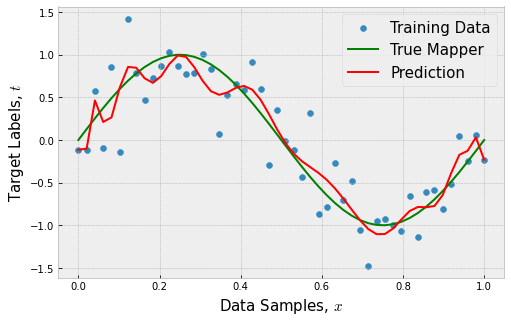

In [26]:
# Pipeline with polynomial features with a linear regression model
M = 20
model = Pipeline([('pol_feat', PolynomialFeatures(degree=M)),
                 ('lin_reg', LinearRegression())])

# Train model
model.fit(x_train, t_train)

# Parameters w
w = np.hstack((model.named_steps['lin_reg'].intercept_, 
               model.named_steps['lin_reg'].coef_[1:])).reshape(-1,1)

# Make predictions
y_train = model.predict(x_train)

# Plotting results
plt.figure(figsize=(8,5))
plt.scatter(x_train, t_train, label='Training Data')
plt.plot(x_true, t_true, 'g', label = 'True Mapper')
plt.plot(x_train, y_train, c='r', label='Prediction')
plt.legend(fontsize=15)
plt.xlabel('Data Samples, $x$',size=15)
plt.ylabel('Target Labels, $t$',size=15);

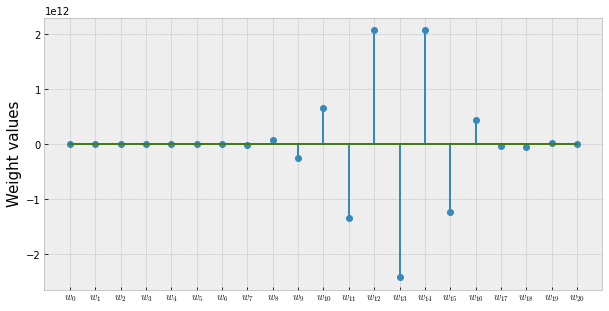

In [27]:
plt.figure(figsize=(10,5))
plt.stem(w)
plt.ylabel('Weight values', size=15)
plt.xticks(np.arange(len(w)), ['$w_{'+str(i)+'}$' for i in range(len(w))],rotation=0);

### Ridge Regularizer

The Ridge regularizer, also known as the L2-Norm regularizer or weight decay, adds a term with the squared sum of the weights scaled by the hyperparameter $\lambda$. 

\begin{align*}
R^{(L2)}_{\mathbf{w}} &= \lambda \sum_{i=0}^M w_i^2 \\
&= \lambda \Vert\mathbf{w}\Vert_2^2
\end{align*}

This forces the learning algorithm to not only fit the data but also keep the model weights as small as possible. Note that the regularization term should only be added to the objective function during training. Once the model is trained, you want to evaluate the model's performance using the unregularized performance measure.

* The hyperparameter $\lambda$ controls how much you want to regularize the model. If $\lambda$ is 0 then the learning algorithm will just minimize the error term in the cost function. If $\lambda$ is very large, then all weights end up very close to zero and the result is a flat line going through the data’s mean.

### Lasso Regularizer

The Lasso regularizer, also known as the L1-norm regularizer, it adds a term with the L1-norm of the weight vector $\mathbf{w}$ scaled by the hyperparameter $\lambda$. $\lambda$ here has the same tradeoff responsibility.

\begin{align*}
R^{(L1)}_{\mathbf{w}} &= \lambda \sum_{i=0}^M |w_i| \\
&= \lambda \Vert\mathbf{w}\Vert_1
\end{align*}

* An important characteristic of the Lasso regularizer is that it tends to eliminate the weights of the least important features by setting them to zero. This is known as **sparsity**.

### Elastic Net Regularizer

Elastic Net is a middle ground between Ridge and Lasso. The regularization term is a simple mix of both Ridge and Lasso's regularization terms, and you can control the mix ratio with the hyperparameter $\beta$.

\begin{align*}
R^{(L12)}_{\mathbf{w}} &= \beta\lambda \sum_{i=0}^M |w_i| + (1-\beta) \lambda \sum_{i=0}^M w_i^2 \\
&= \beta R^{(L1)}_{\mathbf{w}} + (1-\beta) R^{(L2)}_{\mathbf{w}}
\end{align*}

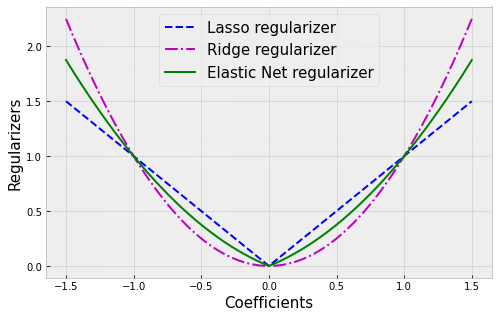

In [29]:
def Regularizers(w,beta=0.5):
    L1 = np.abs(w)
    L2 = w**2
    Elastic = beta*np.abs(w) + (1-beta)*w**2
    return L1, L2, Elastic

x = np.linspace(-1.5,1.5,1000)
L1,L2,Elastic=Regularizers(x)

plt.figure(figsize=(8,5))
plt.plot(x,L1, 'b--', label = 'Lasso regularizer')
plt.plot(x,L2, 'm-.', label = 'Ridge regularizer')
plt.plot(x,Elastic, 'g-', label = 'Elastic Net regularizer')
plt.xlabel('Coefficients',size=15)
plt.ylabel('Regularizers',size=15); plt.legend(fontsize=15);

#### Observations

* Ridge regularizer:
    * forces parameter values to be small but not equal to zero
    * is highly affected by outliers

* Lasso regularizer:
    * promotes sparsity, i.e. forces some parameter values to be exactly equal to zero
    * it is not as affected by outliers
    
* Elastic Net regularizer:
    * requires fine-tuning of an extra hyperparameter

#### Examples

* Consider $\mathbf{w}=[0.5,0.5,1]$. We find that the rigde regularizer is $R^{(L2)}_{\mathbf{w}} = 0.5^2+0.5^2+1^2 = 1.5$, whereas the lasso regularizer gives us $R^{(L1)}_{\mathbf{w}}=0.5+0.5+1=2$. Thus, for this set of coefficients, the lasso regularizer will apply a stronger penalty (larger value).

* Consider $\mathbf{w}=[0,0,2]$. We find that the rigde regularizer is $R^{(L2)}_{\mathbf{w}} = 0^2+0^2+2^2 = 4$, whereas the lasso regularizer gives us $R^{(L1)}_{\mathbf{w}}=0+0+2=2$. Thus, for this set of coefficients, the ridge regularizer will apply a stronger penalty (larger value).

#### Which one to choose?

Ridge is a good default, but if you suspect that only a few features are actually useful, you should prefer Lasso or Elastic Net since they tend to reduce the useless features' weights down to zero. In general, Elastic Net is preferred over Lasso since Lasso may behave erratically when the number of features is greater than the number of training instances or when several features are strongly correlated.

---